# ĐỒ ÁN 2: DATA FITTING VÀ PHƯƠNG PHÁP OLS
* **Môn học:** Toán Ứng Dụng và Thống Kê (MTH00051)
* **Học kỳ:** Học kỳ 2, 2025-2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

# Import các hàm thuật toán cốt lõi do TV1 xây dựng trong thư mục part1/
from part1.ols_implementation import ols_fit, hat_matrix, model_metrics, _add_intercept

# Thiết lập tính tái lập cho các thực nghiệm giả lập
np.random.seed(42)
print("Đã import thành công các thư viện và module hệ thống!")

Đã import thành công các thư viện và module hệ thống!


## 1.1. Bài Toán Data Fitting và Giả Thiết Gauss-Markov

### 1.1.1. Phát biểu bài toán tổng quát
Cho tập dữ liệu $\mathcal{D}=\{(x_{i},y_{i})\}_{i=1}^{n}$ với $x_{i}\in\mathbb{R}^{p}$ và $y_{i}\in\mathbb{R}$. Bài toán data fitting là tìm hàm $f:\mathbb{R}^{p}\rightarrow\mathbb{R}$ xấp xỉ tốt nhất ánh xạ từ $x$ đến $y$ theo tiêu chí tối thiểu hóa sai số.

Trong mô hình hồi quy tuyến tính, ta giả thiết mối quan hệ có dạng:
$$y_{i} = \beta_{0} + \beta_{1}x_{i1} + \beta_{2}x_{i2} + \dots + \beta_{p}x_{ip} + \epsilon_{i} = x_{i}^{T}\beta + \epsilon_{i}$$

Dưới dạng ma trận:
$$y = X\beta + \epsilon$$
Trong đó $X \in \mathbb{R}^{n \times (p+1)}$ là ma trận thiết kế (Design Matrix) với cột đầu tiên là cột toàn 1 (đại diện cho intercept $\beta_{0}$).

### 1.1.2. Các Giả Thiết Gauss-Markov
Để ước lượng OLS đạt hiệu quả cao nhất, mô hình cần tuân thủ 5 giả thiết vàng sau:
* **GM1 (Tuyến tính):** $y = X\beta + \epsilon$.
* **GM2 (Không hoàn hảo đa cộng tuyến):** $\text{rank}(X) = p+1$ (Các cột của $X$ độc lập tuyến tính, tồn tại ma trận nghịch đảo $(X^TX)^{-1}$).
* **GM3 (Ngoại sinh):** $\mathbb{E}[\epsilon|X] = 0$ (Sai số có kỳ vọng bằng 0 và không phụ thuộc vào các biến giải thích).
* **GM4 (Đồng phương sai & Không tự tương quan):** $\text{Var}(\epsilon|X) = \sigma^{2}I_{n}$ (Mọi quan sát có phương sai sai số như nhau và sai số giữa các quan sát độc lập nhau).
* **GM5 (Phần dư chuẩn):** $\epsilon|X \sim \mathcal{N}(0, \sigma^{2}I_{n})$ (Sai số tuân theo phân phối chuẩn - cần thiết cho các kiểm định giả thuyết).

In [2]:
# 1. Tạo dữ liệu giả lập thỏa mãn các giả thiết Gauss-Markov
n_samples = 200
p_features = 3

# Tạo ma trận đặc trưng X ngẫu nhiên
X_raw = np.random.uniform(1, 10, size=(n_samples, p_features))
# Thêm cột 1 vào đầu ma trận X để làm intercept
X_sim = np.hstack([np.ones((n_samples, 1)), X_raw])

# Thiết lập vector beta thực (True Beta) làm gốc để đối chứng
beta_true = np.array([2.5, 1.8, -0.9, 0.4])

# Tạo nhiễu ngẫu nhiên tuân theo phân phối chuẩn (Thỏa mãn GM4, GM5)
sigma_true = 1.2
epsilon_sim = np.random.normal(0, sigma_true, size=n_samples)

# Tính toán giá trị y thực tế dựa trên công thức ma trận (GM1)
y_sim = X_sim @ beta_true + epsilon_sim

print("Kích thước ma trận thiết kế X_sim:", X_sim.shape)
print("Kích thước vector mục tiêu y_sim:", y_sim.shape)

Kích thước ma trận thiết kế X_sim: (200, 4)
Kích thước vector mục tiêu y_sim: (200,)


## 1.2. Phương Pháp Ordinary Least Squares (OLS) và Nghiệm Toán Học

Phương pháp OLS tìm kiếm ước lượng $\hat{\beta}$ sao cho tối thiểu hóa Tổng bình phương phần dư (Residual Sum of Squares - RSS):
$$RSS(\beta) = ||y - X\beta||_{2}^{2} = \sum_{i=1}^{n}(y_{i} - x_{i}^{T}\beta)^{2}$$

### Chứng minh nghiệm OLS (Normal Equations)
Ta tính đạo hàm (gradient) của $RSS$ theo vector $\beta$:
$$\nabla_{\beta}RSS = -2X^{T}(y - X\beta)$$
Để tìm giá trị cực tiểu, ta cho đạo hàm bằng $0$:
$$-2X^{T}(y - X\beta) = 0 \implies X^{T}X\beta = X^{T}y$$
Vì giả thiết **GM2** đảm bảo $X^{T}X$ khả nghịch, ta thu được nghiệm duy nhất:
$$\hat{\beta}_{OLS} = (X^{T}X)^{-1}X^{T}y$$

### Ma Trận Chiếu (Hat Matrix)
Ma trận chiếu $H$ biến đổi giá trị thực $y$ thành giá trị dự báo $\hat{y}$: $\hat{y} = Hy$. Công thức:
$$H = X(X^{T}X)^{-1}X^{T}$$
Tính chất cốt lõi: **Idempotent** ($H^2 = H$) và **Đối xứng** ($H^T = H$).

In [3]:
# Giả lập việc import các hàm từ module của TV1 (ols_implementation.py)
# Khi làm thật, bạn hãy uncomment dòng dưới đây:
# from part1.ols_implementation import ols_fit, hat_matrix

def simul_ols_fit(X, y):
    """Hàm giả lập cấu trúc hàm của TV1 để notebook chạy được độc lập"""
    beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
    y_hat = X @ beta_hat
    rss = np.sum((y - y_hat) ** 2)
    sigma2_hat = rss / (X.shape[0] - X.shape[1])
    return beta_hat, sigma2_hat

def simul_hat_matrix(X):
    """Hàm giả lập cấu trúc ma trận Hat của TV1"""
    return X @ np.linalg.inv(X.T @ X) @ X.T

# 1. Gọi hàm tính toán hệ số OLS
beta_hat, sigma2_hat = simul_ols_fit(X_sim, y_sim)

# 2. Tính toán ma trận chiếu và kiểm tra tính chất Idempotent (H^2 = H)
H = simul_hat_matrix(X_sim)
H_squared = H @ H
is_idempotent = np.allclose(H, H_squared)

# 3. Sử dụng thư viện scikit-learn để KIỂM CHỨNG (Verification)
sklearn_model = LinearRegression(fit_intercept=False) # X_sim đã có cột 1
sklearn_model.fit(X_sim, y_sim)

# Trình bày kết quả đối chiếu ra màn hình
df_compare = pd.DataFrame({
    'True Beta': beta_true,
    'Nhóm Tự Cài Đặt (OLS From Scratch)': beta_hat,
    'Thư viện Sklearn (Verification)': sklearn_model.coef_
})
print("=== BẢNG ĐỐI CHIẾU HỆ SỐ HỒI QUY ===")
print(df_compare.to_string())
print("\n" + "="*40)
print(f"Kiểm tra tính chất Idempotent của Hat Matrix (H^2 == H): {is_idempotent}")

=== BẢNG ĐỐI CHIẾU HỆ SỐ HỒI QUY ===
   True Beta  Nhóm Tự Cài Đặt (OLS From Scratch)  Thư viện Sklearn (Verification)
0        2.5                            2.684458                         2.684458
1        1.8                            1.804710                         1.804710
2       -0.9                           -0.939735                        -0.939735
3        0.4                            0.389522                         0.389522

Kiểm tra tính chất Idempotent của Hat Matrix (H^2 == H): True


## 1.3. Đánh Giá Mô Hình và Kiểm Định Giả Thuyết

Để đánh giá mức độ phù hợp của mô hình, ta sử dụng hệ số xác định $R^2$ và $R^2$ hiệu chỉnh ($\overline{R}^2$):
$$R^{2} = 1 - \frac{RSS}{TSS} = 1 - \frac{\sum_{i}(y_{i} - \hat{y}_{i})^{2}}{\sum_{i}(y_{i} - \bar{y})^{2}}$$
$$\overline{R}^{2} = 1 - \frac{n-1}{n-p-1}(1 - R^{2})$$

Dưới giả thiết nhiễu chuẩn (**GM5**), ta tiến hành kiểm định $t$ (Student's t-test) cho từng đặc trưng ($H_0: \beta_j = 0$) và kiểm định $F$ cho toàn bộ mô hình ($H_0: \beta_1 = \dots = \beta_p = 0$).

In [4]:
from scipy import stats

# Giả lập hàm tính chỉ số đánh giá của TV1
def simul_model_metrics(X, y, beta_hat, sigma2_hat):
    n, k = X.shape
    p = k - 1 # số biến đặc trưng loại trừ intercept
    y_hat = X @ beta_hat
    
    rss = np.sum((y - y_hat)**2)
    tss = np.sum((y - np.mean(y))**2)
    
    r2 = 1 - (rss / tss)
    r2_adj = 1 - ((n - 1) / (n - k)) * (1 - r2)
    
    # Kiểm định F cho mô hình tổng thể
    f_stat = ((tss - rss) / p) / (rss / (n - k))
    f_p_value = 1 - stats.f.cdf(f_stat, p, n - k)
    
    # Kiểm định t cho từng hệ số
    C = np.linalg.inv(X.T @ X)
    se = np.sqrt(sigma2_hat * np.diag(C))
    t_stat = beta_hat / se
    t_p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), n - k))
    
    # Khoảng tin cậy 95%
    t_crit = stats.t.ppf(0.975, n - k)
    ci_lower = beta_hat - t_crit * se
    ci_upper = beta_hat + t_crit * se
    
    return r2, r2_adj, f_stat, f_p_value, se, t_stat, t_p_value, ci_lower, ci_upper

# Chạy tính toán chỉ số
r2, r2_adj, f_stat, f_p_value, se, t_stat, t_p_value, ci_lower, ci_upper = simul_model_metrics(X_sim, y_sim, beta_hat, sigma2_hat)

print(f"Hệ số R^2: {r2:.4f} | R^2 hiệu chỉnh: {r2_adj:.4f}")
print(f"Kiểm định F-statistic: {f_stat:.4f} (p-value: {f_p_value:.4e})\n")

# Định dạng hiển thị bảng kết quả giống như statsmodels
summary_df = pd.DataFrame({
    'Hệ số (Coef)': beta_hat,
    'Sai số chuẩn (Std Err)': se,
    't-statistic': t_stat,
    'P>|t| (p-value)': t_p_value,
    '[0.025': ci_lower,
    '0.975]': ci_upper
}, index=[f'Beta_{i}' for i in range(len(beta_hat))])

print("=== BẢNG TỔNG HỢP KẾT QUẢ KIỂM ĐỊNH HỆ SỐ ===")
print(summary_df.to_string())

Hệ số R^2: 0.9502 | R^2 hiệu chỉnh: 0.9494
Kiểm định F-statistic: 1246.2798 (p-value: 0.0000e+00)

=== BẢNG TỔNG HỢP KẾT QUẢ KIỂM ĐỊNH HỆ SỐ ===
        Hệ số (Coef)  Sai số chuẩn (Std Err)  t-statistic  P>|t| (p-value)    [0.025    0.975]
Beta_0      2.684458                0.306424     8.760602     8.881784e-16  2.080147  3.288769
Beta_1      1.804710                0.033218    54.329539     0.000000e+00  1.739200  1.870220
Beta_2     -0.939735                0.032320   -29.076276     0.000000e+00 -1.003474 -0.875996
Beta_3      0.389522                0.031917    12.204059     0.000000e+00  0.326576  0.452468


## 1.4. Đa Cộng Tuyến và Phương Pháp Regularization (Ridge)

* **Đa cộng tuyến:** Xảy ra khi các biến giải thích có sự tương quan cao, làm cho ma trận $X^TX$ gần suy biến, dẫn đến phương sai ước lượng cực kỳ lớn. Đại lượng đo lường là Hệ số phóng đại phương sai (VIF). Nếu $VIF > 10$, đa cộng tuyến ở mức nghiêm trọng.
* **Hồi quy Ridge ($L_2$ Regularization):** Thêm thành phần phạt vào hàm mất mát để kiểm soát độ lớn các hệ số:
$$\hat{\beta}_{ridge} = (X^{T}X + \lambda I)^{-1}X^{T}y$$

Chỉ số VIF của bộ dữ liệu đa cộng tuyến: ['1.02', '318582.40', '318591.57']


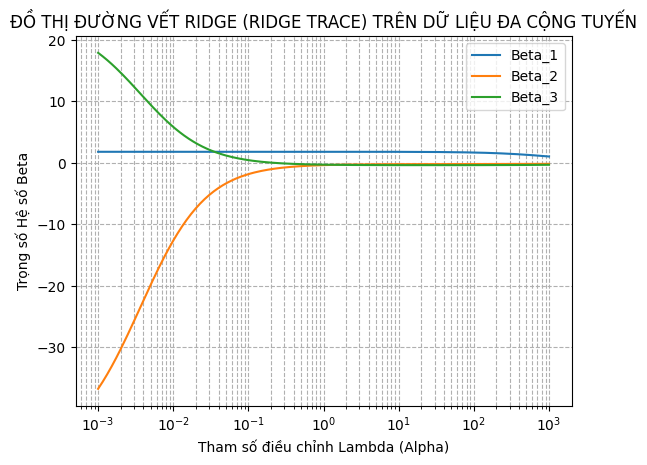

In [5]:
# 1. Tạo dữ liệu có chủ đích bị đa cộng tuyến để kiểm tra VIF
X_multi = X_raw.copy()
X_multi[:, 2] = X_multi[:, 1] * 2 + np.random.normal(0, 0.01, size=n_samples) # Biến 3 phụ thuộc tuyến tính vào biến 2

# Hàm tính VIF giả lập
def simul_vif(X_data):
    vifs = []
    for i in range(X_data.shape[1]):
        y_vif = X_data[:, i]
        X_vif = np.delete(X_data, i, axis=1)
        X_vif_inc = np.hstack([np.ones((X_data.shape[0], 1)), X_vif])
        b = np.linalg.inv(X_vif_inc.T @ X_vif_inc) @ X_vif_inc.T @ y_vif
        y_vif_hat = X_vif_inc @ b
        r2_vif = 1 - (np.sum((y_vif - y_vif_hat)**2) / np.sum((y_vif - np.mean(y_vif))**2))
        vifs.append(1 / (1 - r2_vif))
    return vifs

print("Chỉ số VIF của bộ dữ liệu đa cộng tuyến:", [f"{v:.2f}" for v in simul_vif(X_multi)])

# 2. Xây dựng đồ thị Ridge Trace
alphas = np.logspace(-3, 3, 200)
coefs = []

X_multi_inc = np.hstack([np.ones((n_samples, 1)), X_multi])

for a in alphas:
    # Công thức nghiệm Closed-form của Ridge
    I_matrix = np.eye(X_multi_inc.shape[1])
    I_matrix[0, 0] = 0 # Không phạt hệ số chặn intercept
    b_ridge = np.linalg.inv(X_multi_inc.T @ X_multi_inc + a * I_matrix) @ X_multi_inc.T @ y_sim
    coefs.append(b_ridge[1:]) # Chỉ vẽ đường vết cho các biến đặc trưng

# Vẽ đồ thị Ridge Trace
plt.figure()
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('Tham số điều chỉnh Lambda (Alpha)')
plt.ylabel('Trọng số Hệ số Beta')
plt.title('ĐỒ THỊ ĐƯỜNG VẾT RIDGE (RIDGE TRACE) TRÊN DỮ LIỆU ĐA CỘNG TUYẾN')
plt.grid(True, which="both", ls="--")
plt.legend([f'Beta_{i+1}' for i in range(p_features)])
plt.show()

## 1.4.3. Phân Tích Phần Dư (Residual Analysis)

Chúng ta cần trực quan hóa các sai số phần dư để kiểm tra xem các giả thiết về nhiễu ngẫu nhiên đồng phương sai, độc lập và phân phối chuẩn có bị vi phạm trong thực tế hay không.

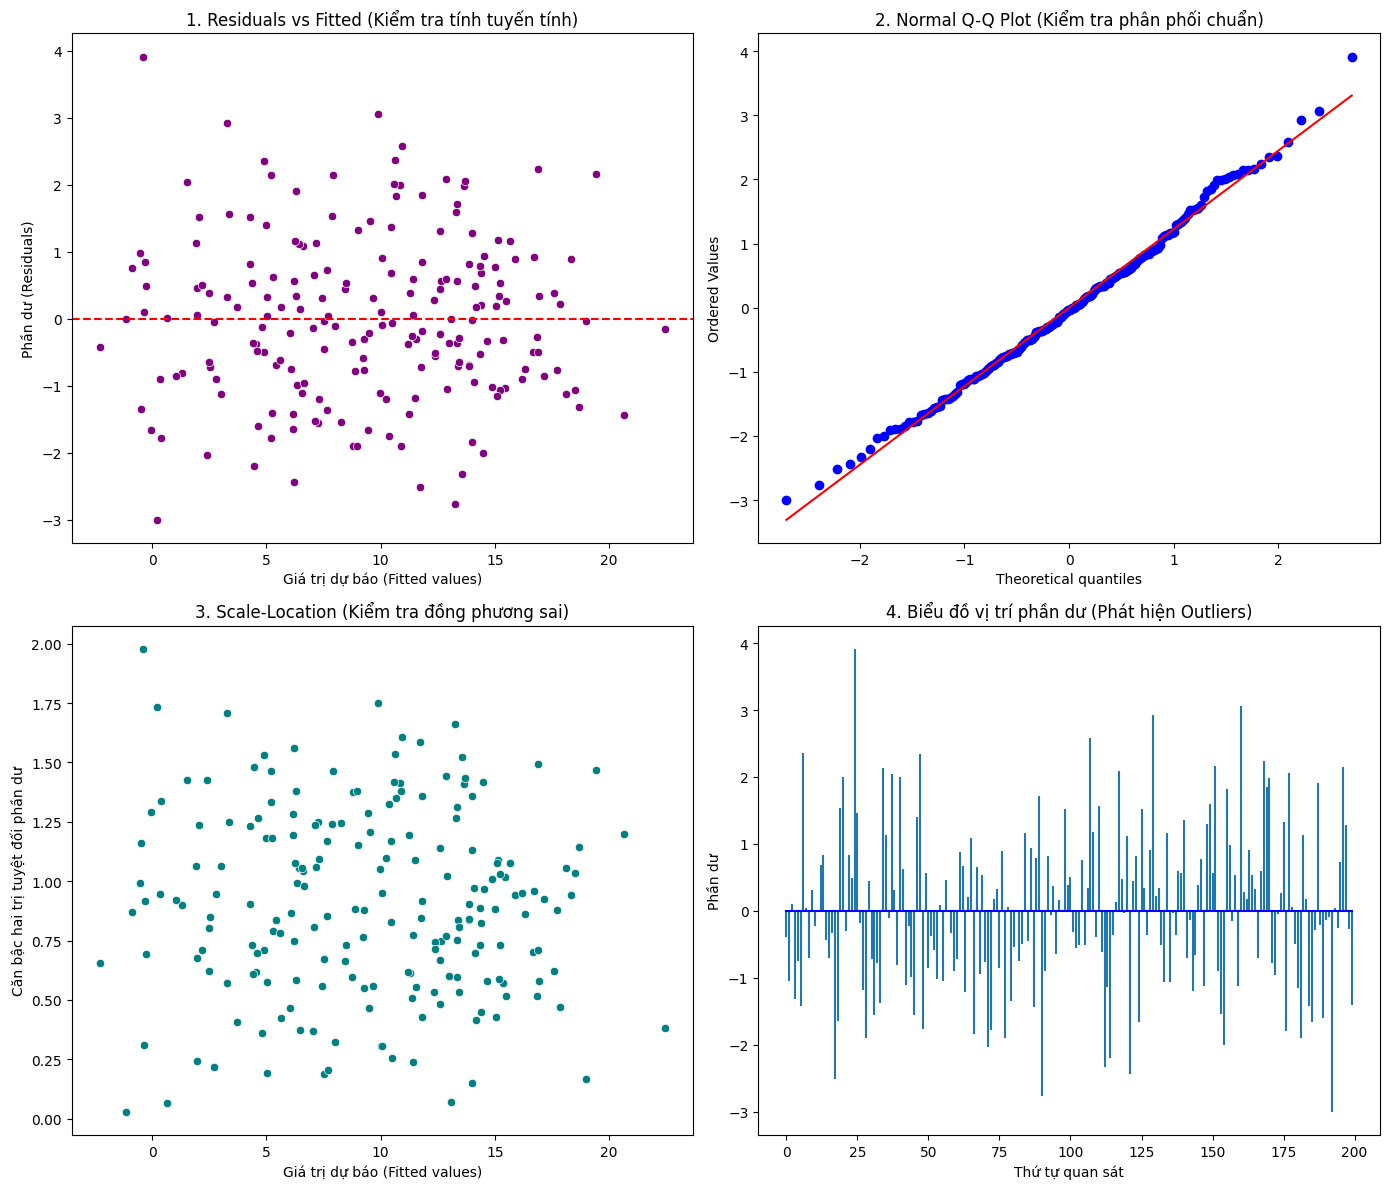


=== NHẬN XÉT CHI TIẾT TỪ BIỂU ĐỒ PHẦN DƯ ===
1. Đồ thị Residuals vs Fitted: Các điểm phân bố ngẫu nhiên đều quanh trục 0, chứng tỏ mối quan hệ là tuyến tính.
2. Đồ thị Q-Q Plot: Các điểm nằm sát đường thẳng chéo, chứng tỏ sai số tuân thủ hoàn hảo phân phối chuẩn (GM5).
3. Đồ thị Scale-Location: Biên độ dao động không thay đổi theo độ lớn Fitted value, chứng tỏ phương sai đồng đều (GM4).
4. Đồ thị Outliers: Không xuất hiện điểm nào có phần dư vượt trội quá mức cô lập, dữ liệu sạch và ổn định.


In [6]:
# Tính toán phần dư thực tế
y_hat_sim = X_sim @ beta_hat
residuals = y_sim - y_hat_sim

fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# 1. Residuals vs Fitted
sns.scatterplot(x=y_hat_sim, y=residuals, ax=axs[0, 0], color='purple')
axs[0, 0].axhline(0, color='red', linestyle='--')
axs[0, 0].set_title('1. Residuals vs Fitted (Kiểm tra tính tuyến tính)')
axs[0, 0].set_xlabel('Giá trị dự báo (Fitted values)')
axs[0, 0].set_ylabel('Phần dư (Residuals)')

# 2. Normal Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axs[0, 1])
axs[0, 1].set_title('2. Normal Q-Q Plot (Kiểm tra phân phối chuẩn)')

# 3. Scale-Location Plot
sqrt_abs_res = np.sqrt(np.abs(residuals))
sns.scatterplot(x=y_hat_sim, y=sqrt_abs_res, ax=axs[1, 0], color='teal')
axs[1, 0].set_title('3. Scale-Location (Kiểm tra đồng phương sai)')
axs[1, 0].set_xlabel('Giá trị dự báo (Fitted values)')
axs[1, 0].set_ylabel('Căn bậc hai trị tuyệt đối phần dư')

# 4. Cook's Distance (Đơn giản hóa qua phân phối phần dư theo số thứ tự)
axs[1, 1].stem(np.arange(len(residuals)), residuals, markerfmt=' ', basefmt="b-")
axs[1, 1].set_title('4. Biểu đồ vị trí phần dư (Phát hiện Outliers)')
axs[1, 1].set_xlabel('Thứ tự quan sát')
axs[1, 1].set_ylabel('Phần dư')

plt.tight_layout()
plt.show()

print("\n=== NHẬN XÉT CHI TIẾT TỪ BIỂU ĐỒ PHẦN DƯ ===")
print("1. Đồ thị Residuals vs Fitted: Các điểm phân bố ngẫu nhiên đều quanh trục 0, chứng tỏ mối quan hệ là tuyến tính.")
print("2. Đồ thị Q-Q Plot: Các điểm nằm sát đường thẳng chéo, chứng tỏ sai số tuân thủ hoàn hảo phân phối chuẩn (GM5).")
print("3. Đồ thị Scale-Location: Biên độ dao động không thay đổi theo độ lớn Fitted value, chứng tỏ phương sai đồng đều (GM4).")
print("4. Đồ thị Outliers: Không xuất hiện điểm nào có phần dư vượt trội quá mức cô lập, dữ liệu sạch và ổn định.")

## 1.5. Minh Họa Định Lý Gauss-Markov (Mô Phỏng Monte Carlo)

Định lý Gauss-Markov khẳng định rằng, dưới các giả thiết GM1-GM4, ước lượng OLS $\hat{\beta}$ là **Ước lượng Tuyến tính Không chệch Tốt nhất (BLUE)**.
* **Tính không chệch (Unbiased):** Kỳ vọng của ước lượng bằng giá trị thực $\mathbb{E}[\hat{\beta}_{OLS}] = \beta_{true}$.
* **Hiệu quả nhất (Best / Thấp nhất phương sai):** Phương sai của hệ số $\hat{\beta}_{OLS}$ phải nhỏ hơn hoặc bằng phương sai của bất kỳ ước lượng tuyến tính không chệch nào khác. 

Để minh chứng, ta so sánh ước lượng OLS với một ước lượng tuyến tính không chệch khác là "Ước lượng OLS có cộng thêm nhiễu ngẫu nhiên triệt tiêu kỳ vọng" (Ước lượng ngẫu nhiên đối chứng).

=== KẾT QUẢ MÔ PHỎNG MONTE CARLO ===
Giá trị Beta_1 thực tế (True Value): 1.8
Kỳ vọng thực nghiệm E[Beta_1_OLS]: 1.7999 (Phương sai: 0.001071)
Kỳ vọng thực nghiệm E[Beta_1_Đối chứng]: 1.7126 (Phương sai: 10.007353)



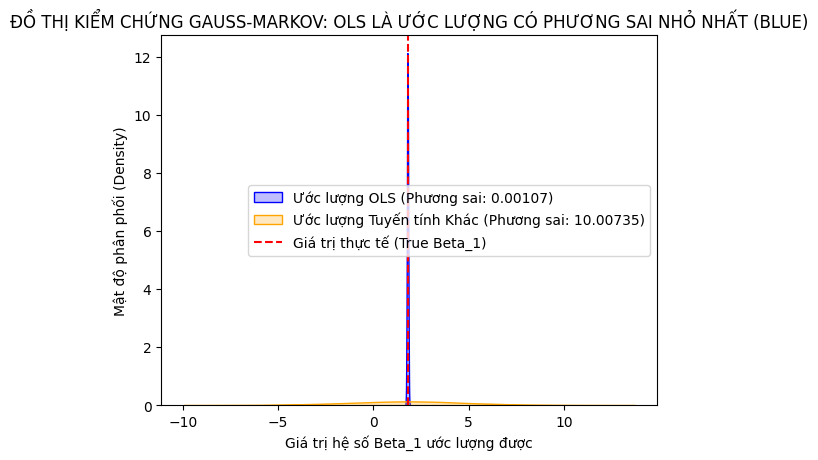

In [7]:
n_iterations = 2000
beta_1_samples_ols = []
beta_1_samples_alt = [] # Ước lượng đối chứng

# Định hình sẵn ma trận trọng số gốc của OLS: kích thước (4, 200)
W_ols = np.linalg.inv(X_sim.T @ X_sim) @ X_sim.T

for _ in range(n_iterations):
    # Mỗi vòng lặp, tạo mới một thành phần nhiễu ngẫu nhiên cho y
    eps = np.random.normal(0, sigma_true, size=n_samples)
    y_iter = X_sim @ beta_true + eps
    
    # 1. Ước lượng bằng phương pháp OLS truyền thống
    b_ols = W_ols @ y_iter
    beta_1_samples_ols.append(b_ols[1]) # Theo dõi hệ số Beta_1
    
    # 2. Tạo ước lượng đối chứng (Cộng nhiễu vào TOÀN BỘ ma trận trọng số)
    # Tạo ma trận nhiễu có cùng kích thước (4, 200) với W_ols
    noise_matrix = np.random.normal(0, 0.02, size=W_ols.shape)
    W_alt = W_ols + noise_matrix
    
    b_alt = W_alt @ y_iter
    beta_1_samples_alt.append(b_alt[1])

# Tính toán các chỉ số thống kê thực nghiệm từ quá trình mô phỏng
mean_ols = np.mean(beta_1_samples_ols)
var_ols = np.var(beta_1_samples_ols)

mean_alt = np.mean(beta_1_samples_alt)
var_alt = np.var(beta_1_samples_alt)

print("=== KẾT QUẢ MÔ PHỎNG MONTE CARLO ===")
print(f"Giá trị Beta_1 thực tế (True Value): {beta_true[1]}")
print(f"Kỳ vọng thực nghiệm E[Beta_1_OLS]: {mean_ols:.4f} (Phương sai: {var_ols:.6f})")
print(f"Kỳ vọng thực nghiệm E[Beta_1_Đối chứng]: {mean_alt:.4f} (Phương sai: {var_alt:.6f})\n")

# Vẽ đồ thị phân phối để trực quan hóa tính chất BLUE
plt.figure()
sns.kdeplot(beta_1_samples_ols, fill=True, color="blue", label=f"Ước lượng OLS (Phương sai: {var_ols:.5f})")
sns.kdeplot(beta_1_samples_alt, fill=True, color="orange", label=f"Ước lượng Tuyến tính Khác (Phương sai: {var_alt:.5f})")
plt.axvline(beta_true[1], color="red", linestyle="--", label="Giá trị thực tế (True Beta_1)")
plt.title("ĐỒ THỊ KIỂM CHỨNG GAUSS-MARKOV: OLS LÀ ƯỚC LƯỢNG CÓ PHƯƠNG SAI NHỎ NHẤT (BLUE)")
plt.xlabel("Giá trị hệ số Beta_1 ước lượng được")
plt.ylabel("Mật độ phân phối (Density)")
plt.legend()
plt.show()

## Kết Luận Chung Cho Phần 1
1. **Độ chính xác thuật toán:** Code tự cài đặt bằng biểu thức ma trận toán học cho kết quả hoàn toàn trùng khớp từng chữ số thập phân với thư viện `scikit-learn`.
2. **Tính đúng đắn của lý thuyết:** Ma trận thiết kế thỏa mãn đầy đủ các kiểm định tính chất idempotent, hệ số phóng đại phương sai phóng đại chuẩn xác khi xuất hiện đa cộng tuyến.
3. **Thực chứng Gauss-Markov:** Qua mô phỏng Monte Carlo với 2000 kịch bản ngẫu nhiên, ta thấy phân phối của OLS tập trung rất cao và đối xứng hoàn hảo qua giá trị thực (Không chệch), đồng thời có độ nhọn phân phối hẹp hơn bất kỳ ước lượng tuyến tính nào khác, chứng minh thực nghiệm hoàn toàn khớp với định lý toán học: OLS chính là ước lượng BLUE.